<font face="Arial" size="4" color="black">

## Stabilizer states

This code uses the QuTiP library to create a 3D visualization of a Bloch Sphere that highlights the 6 Stabilizer States (also known as the "cardinal points") of a single qubit.

1. Setting up the Sphere:

   - b = Bloch(): Initializes a standard Bloch Sphere object.
   - b.add_vectors([[1,0,0], [0,1,0], [0,0,1]]): Draws three arrows (vectors) starting from the center, pointing to the +X, +Y, and +Z poles to define the coordinate system.

2. Defining the 6 Stabilizer States

   The code defines 6 points (pnt1 through pnt6) representing the most fundamental states in quantum error correction:

   - Z-axis: |0⟩ (Top) and |1⟩(Bottom)
   - X-axis: |+⟩ (Front) and |-⟩(Back)
   - Y-axis: |+i⟩ (Left) and |-i⟩ (Right)
     
     
3. Drawing the Geometry (The Octahedron)

   The main part of the code connects these points with black lines (b.add_line) to create a geometric shape called an octahedron (it looks like two square-based pyramids joined at the base):

   - The Equator: It connects the X and Y points to form a square in the middle of the sphere
   - The Top/Bottom Caps: It draws lines from the North Pole (+Z) and South Pole (-Z) to every point on that middle square.
     
4. Visualization

   - b.point_color = ['r']: Makes the 6 points appear as red dots
   - b.show(): Renders the final 3D plot

</font>

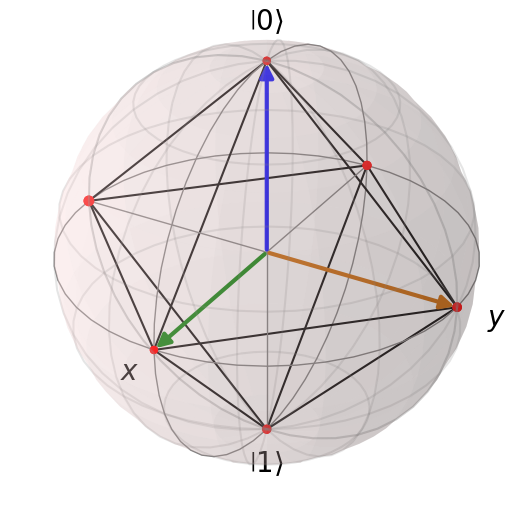

In [2]:
from qutip import Bloch
from matplotlib import pyplot as plt
import numpy as np


# 1. Create the sphere
b = Bloch()

# Draw three arrows (vectors) starting from the center, pointing to the +X, +Y, and +Z poles to define the coordinate system.
vec = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
b.add_vectors(vec)

# 2. Define the 6 Stabilizer States

pnt1=[1, 0, 0]
pnt2=[-1, 0, 0]
pnt3=[0, 1, 0]
pnt4=[0, -1, 0]
pnt5= [0, 0, 1]
pnt6 = [0, 0, -1]

b.point_color = ['r']
b.point_marker = ['o']

b.add_points(pnt1)
b.add_points(pnt2)
b.add_points(pnt3)
b.add_points(pnt4)
b.add_points(pnt5)
b.add_points(pnt6)

# 3. Draw the Geometry (The Octahedron)
line_color = 'k' # Black lines
# Connect the square in the middle (XY plane)
b.add_line(pnt1, pnt3, color=line_color) # X+ to Y+
b.add_line(pnt2, pnt3, color=line_color) # X- to Y+
b.add_line(pnt2, pnt4, color=line_color) # X- to Y-
b.add_line(pnt1, pnt4, color=line_color) # X+ to Y-

# Connect to the Top Pole
b.add_line(pnt5, pnt1, color=line_color) # Z+ to X+
b.add_line(pnt5, pnt2, color=line_color) # Z+ to X-
b.add_line(pnt5, pnt3, color=line_color) # Z+ to Y+
b.add_line(pnt5, pnt4, color=line_color) # Z+ to Y-

# Connect to the Bottom Pole
b.add_line(pnt6, pnt1, color=line_color) # Z- to X+
b.add_line(pnt6, pnt2, color=line_color) # Z- to X-
b.add_line(pnt6, pnt3, color=line_color) # Z- to Y+
b.add_line(pnt6, pnt4, color=line_color) # Z- to Y-

# 4. Show it
b.show()

bb = b.fig
#bb.savefig('Stabilizer_States_Bloch.png')


<font face="Arial" size="4" color="black">

## Non-stabilizer states

Here, we will add Magic States (specifically the T-states), which are visualized as a Cube nested within the original Octahedron.

   - The Cube: The code calculates 8 new points (t_states) at the corners of a cube (e.g., [± 1, ± 1, ± 1] normalized)
   - These 8 points sit exactly in the center of the 8 triangular faces of the original Octahedron. In quantum mechanics, these represent the states most distant from the stabilizer states, making them "magic" because they allow for operations (like the T-gate) that stabilizers alone cannot perform.

This code uses a neighbor-finding loop. It checks which points are physically next to each other in 3D space (diff_count == 1) to decide where to draw the cyan lines.

</font>

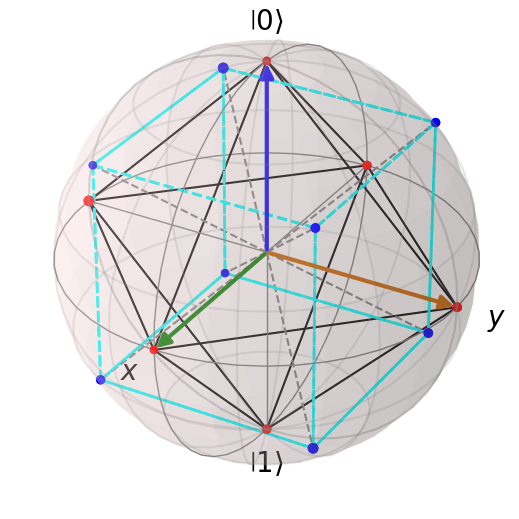

In [3]:
from qutip import Bloch
import numpy as np
import matplotlib.pyplot as plt  # Import this if you save an image

# 1. OCTAHEDRON SETUP 
b = Bloch()
vec = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
b.add_vectors(vec)

pnt1=[1, 0, 0]; pnt2=[-1, 0, 0]; pnt3=[0, 1, 0]; pnt4=[0, -1, 0]
pnt5=[0, 0, 1]; pnt6=[0, 0, -1]

b.point_color = ['r']
b.point_marker = ['o']

b.add_points(pnt1); b.add_points(pnt2); b.add_points(pnt3)
b.add_points(pnt4); b.add_points(pnt5); b.add_points(pnt6)

line_color = 'k'
b.add_line(pnt1, pnt3, color=line_color)
b.add_line(pnt2, pnt3, color=line_color)
b.add_line(pnt2, pnt4, color=line_color)
b.add_line(pnt1, pnt4, color=line_color)
b.add_line(pnt5, pnt1, color=line_color); b.add_line(pnt5, pnt2, color=line_color)
b.add_line(pnt5, pnt3, color=line_color); b.add_line(pnt5, pnt4, color=line_color)
b.add_line(pnt6, pnt1, color=line_color); b.add_line(pnt6, pnt2, color=line_color)
b.add_line(pnt6, pnt3, color=line_color); b.add_line(pnt6, pnt4, color=line_color)


# 2. CUBE SETUP 
raw_cube = [
    [1, 1, 1], [1, 1, -1], [1, -1, 1], [-1, 1, 1],
    [-1, 1, -1], [-1, -1, 1], [-1, -1, -1], [1, -1, -1]
]
t_states = [ [x/np.sqrt(3), y/np.sqrt(3), z/np.sqrt(3)] for x, y, z in raw_cube ]

# Find neighbors dynamically to ensure a perfect cube
neighbors = []
for i, t1 in enumerate(t_states):
    neighbors_list = []
    for j, t2 in enumerate(t_states):
        if i == j: continue
        diff_count = sum(1 for a, b in zip(t1, t2) if a != b)
        if diff_count == 1:
            neighbors_list.append(j)
    neighbors.append(neighbors_list)

# Draw Cube
origin = [0,0,0]
for i, t in enumerate(t_states):
    
    # Draw Normal (Gray)
    b.add_line(origin, t, color='gray', ls='--') 
    
    # Draw Cube Edges (Cyan)
    for n_idx in neighbors[i]:
        b.add_line(t, t_states[n_idx], color='cyan', ls='--', linewidth=2)

    # Draw Points (Blue)
    b.add_points(t, 's', 'b')

# 3. SAVE OR SHOW 

# Option A: Show in Jupyter/Python
b.show()

# Option B: Save to file (Uncomment line below)
bb = b.fig
#bb.savefig('Magic_T_States_Bloch_v3.png', dpi=300, bbox_inches='tight')


<font face="Arial" size="4" color="black">

The main addition in the code below will be the H-states (Hadamard-type magic states), along with specific color-coded highlights for individual magic states.  The H-states are mathematically located at the midpoints of the Octahedron's edges. It takes the 12 edges of the black octahedron, finds their center (midpoint), and "pushes" them out to the surface of the sphere (normalization). These are rendered as green squares ('s', 'g') with gray dashed lines connecting them to the center.

This code manually singles out specific states to make them stand out with different colors:

  - Yellow T-states: We replot two specific corners of the cube (t_magic1 and t_magic2) in yellow to highlight specific states being used in a calculation, like a "T-gate" input.
  - Purple H-states: We manually define and plot two points (h_magic and m_magic) in purple. These are specific H-type states located on the edges of the octahedron (for example, [0.707, 0.707, 0] is the |+⟩ + |+i⟩ superposition).

</font>

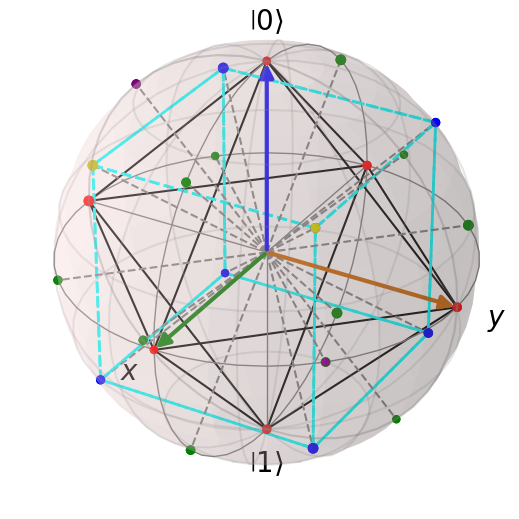

In [4]:
from qutip import Bloch
import numpy as np
import matplotlib.pyplot as plt

# --- 1. OCTAHEDRON SETUP ---
b = Bloch()
vec = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
b.add_vectors(vec)

pnt1=[1, 0, 0]; pnt2=[-1, 0, 0]; pnt3=[0, 1, 0]; pnt4=[0, -1, 0]
pnt5=[0, 0, 1]; pnt6=[0, 0, -1]

b.point_color = ['r']
#b.point_marker = ['o']
b.point_marker = ['o'] 

b.add_points(pnt1); b.add_points(pnt2); b.add_points(pnt3)
b.add_points(pnt4); b.add_points(pnt5); b.add_points(pnt6)

line_color = 'k'
b.add_line(pnt1, pnt3, color=line_color)
b.add_line(pnt2, pnt3, color=line_color)
b.add_line(pnt2, pnt4, color=line_color)
b.add_line(pnt1, pnt4, color=line_color)
b.add_line(pnt5, pnt1, color=line_color); b.add_line(pnt5, pnt2, color=line_color)
b.add_line(pnt5, pnt3, color=line_color); b.add_line(pnt5, pnt4, color=line_color)
b.add_line(pnt6, pnt1, color=line_color); b.add_line(pnt6, pnt2, color=line_color)
b.add_line(pnt6, pnt3, color=line_color); b.add_line(pnt6, pnt4, color=line_color)


# --- 2. CUBE SETUP ---
raw_cube = [
    [1, 1, 1], [1, 1, -1], [1, -1, 1], [-1, 1, 1],
    [-1, 1, -1], [-1, -1, 1], [-1, -1, -1], [1, -1, -1]
]
t_states = [ [x/np.sqrt(3), y/np.sqrt(3), z/np.sqrt(3)] for x, y, z in raw_cube ]

# Find neighbors dynamically to ensure a perfect cube
neighbors = []
for i, t1 in enumerate(t_states):
    neighbors_list = []
    for j, t2 in enumerate(t_states):
        if i == j: continue
        diff_count = sum(1 for a, b in zip(t1, t2) if a != b)
        if diff_count == 1:
            neighbors_list.append(j)
    neighbors.append(neighbors_list)

# Draw Cube
origin = [0,0,0]
for i, t in enumerate(t_states):
    # Draw Normal (Gray)
    b.add_line(origin, t, color='gray', ls='--') 
    
    # Draw Cube Edges (Cyan)
    for n_idx in neighbors[i]:
        b.add_line(t, t_states[n_idx], color='cyan', ls='--', linewidth=2)

    # Draw Points (Blue)
    b.add_points(t, 's', 'b')


# <<< UPDATE: H-STATES (Edges) >>>
# List of the 12 Octahedron Edges to generate H-points
h_octa_edges = [
    [pnt1, pnt3], [pnt2, pnt3], [pnt2, pnt4], [pnt1, pnt4], # Top square
    [pnt5, pnt1], [pnt5, pnt2], [pnt5, pnt3], [pnt5, pnt4], # Right pyramid
    [pnt6, pnt1], [pnt6, pnt2], [pnt6, pnt3], [pnt6, pnt4]  # Left pyramid
]

h_states = []
for start, end in h_octa_edges:
    # Calculate Midpoint
    mx = (start[0] + end[0]) / 2
    my = (start[1] + end[1]) / 2
    mz = (start[2] + end[2]) / 2
    
    # Normalize to surface (Radius 1)
    mag = np.sqrt(mx**2 + my**2 + mz**2)
    h_states.append([mx/mag, my/mag, mz/mag])

# Draw H-states
for h in h_states:
    # Draw Normal (Gray)
    b.add_line(origin, h, color='gray', ls='--')
    b.add_points(h,'s', 'g')

t_magic1= [1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)]
t_magic2= [1/np.sqrt(3), -1/np.sqrt(3), 1/np.sqrt(3)]
b.add_points(t_magic1,'s', 'y')
b.add_points(t_magic2,'s', 'y')

h_magic = [0.70711, 0.70711, 0.0]
b.add_points(h_magic,'s', 'purple')

m_magic = [0, -0.70711, 0.70711]
b.add_points(m_magic,'s', 'purple')

#ccz_vec = unit(np.array([1, 1, 1]))
#b.add_points(ccz_vec, 's', 'orange')

# --- 3. SAVE OR SHOW ---
# Option A: Show in Jupyter/Python
b.show()

# Option B: Save to file (Uncomment line below)
bb = b.fig
#bb.savefig('Magic_T_H_State_Bloch.png', dpi=300, bbox_inches='tight')

In [5]:
from qutip.ipynbtools import version_table

version_table()